# Astronomical Object Clustering Pipeline
## Unsupervised classification of Stars, Galaxies, and Quasars

**Dataset:** 10,000 spectroscopically confirmed observations  
**Task:** Cluster objects by photometric properties — *without* using class labels  
**Evaluation:** Post-hoc comparison of clusters to ground-truth labels (STAR, GALAXY, QSO)


## Part 0: Setup

In [31]:
from astral_pipeline import loader, features, cluster, evaluate, visualise
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [32]:
DATA_PATH = "star-galaxy-quasar.csv"
df_raw = loader.load_raw(DATA_PATH)
print(f"[setup] Raw shape: {df_raw.shape}")

schema_report = loader.validate_schema(df_raw)
quality_report = loader.report_quality(df_raw)

print("[setup] Schema report:")
print(schema_report)

print("\n[setup] Quality report (high-level):")
print({
    "n_rows": quality_report.get("n_rows"),
    "n_cols": quality_report.get("n_cols"),
    "negative_redshift_count": quality_report.get("negative_redshift_count"),
})

[setup] Raw shape: (10000, 10)
[setup] Schema report:
{'is_valid': True, 'missing_columns': [], 'non_numeric_columns': [], 'n_rows': 10000, 'n_cols': 10}

[setup] Quality report (high-level):
{'n_rows': 10000, 'n_cols': 10, 'negative_redshift_count': 241}


In [33]:
df_raw.head(3)

,objid,ra,dec,u,g,r,i,z,class,redshift
0,1237654669735231608,149.142428,-0.372420,19.76743,17.87560,16.90248,16.45606,16.12213,GALAXY,0.091934
1,1237651801233686770,149.117936,0.183976,18.20582,16.46298,15.49704,14.95910,14.60985,GALAXY,0.065808
2,1237651800696881217,149.156198,-0.315231,19.78793,18.33921,17.48833,17.07277,16.74467,GALAXY,0.085327


## Part 1: Data cleaning

### Drop `ra` and `dec`

Right ascension and declination are sky coordinates — they tell us *where* an object is, not *what* it is. In a general photometric survey, all three object types are distributed across the sky with no systematic spatial segregation. These columns add noise to distance calculations.

In [34]:
X_raw, y, df_clean = loader.load_pipeline(
    DATA_PATH,
    drop_coords=True,
    keep_redshift=True,
    remove_invalid=True,
)

print("\n[setup] Pipeline outputs:")
print(f"  X_raw shape:   {X_raw.shape}")
print(f"  y shape:       {y.shape}")

print(f"  df_clean shape:{df_clean.shape}")
print(f"  X_raw columns: {list(X_raw.columns)}")
print(f"  y classes:\n{y.value_counts().to_string()}")


[loader] Removed 256 rows with sentinel/invalid values (2.56% of data).
[loader] Final dataset: 9744 rows, 6 features.
[loader] Class distribution:
class
GALAXY    8434
QSO        685
STAR       625

[setup] Pipeline outputs:
  X_raw shape:   (9744, 6)
  y shape:       (9744,)
  df_clean shape:(9744, 10)
  X_raw columns: ['u', 'g', 'r', 'i', 'z', 'redshift']
  y classes:
class
GALAXY    8434
QSO        685
STAR       625


### Outliers removed
Outliers were identified following these rules:  
1. For each band in u, g, r, i, z:
- value must be strictly between -50 and 50
- so values <= -50 or >= 50 are removed
2. redshift must be >= 0

In [35]:
X_raw.head(3)

,u,g,r,i,z,redshift
0,19.76743,17.87560,16.90248,16.45606,16.12213,0.091934
1,18.20582,16.46298,15.49704,14.95910,14.60985,0.065808
2,19.78793,18.33921,17.48833,17.07277,16.74467,0.085327


In [36]:
df_clean.head(3)

,objid,ra,dec,u,g,r,i,z,class,redshift
0,1237654669735231608,149.142428,-0.372420,19.76743,17.87560,16.90248,16.45606,16.12213,GALAXY,0.091934
1,1237651801233686770,149.117936,0.183976,18.20582,16.46298,15.49704,14.95910,14.60985,GALAXY,0.065808
2,1237651800696881217,149.156198,-0.315231,19.78793,18.33921,17.48833,17.07277,16.74467,GALAXY,0.085327


## Part 2: EDA (Exploratory Data Analysis)

In [37]:
# CORRECT — build X_eda from features only, no y involved
X_eda = X_raw.copy()
X_eda["u-g"] = X_eda["u"] - X_eda["g"]
X_eda["g-r"] = X_eda["g"] - X_eda["r"]
X_eda["r-i"] = X_eda["r"] - X_eda["i"]
X_eda["i-z"] = X_eda["i"] - X_eda["z"]

In [38]:
# Structural bookkeeping — class counts reported for transparency only,
# not used in any downstream analytical decision
print("[Dataset] Class distribution (for transparency only — not used in pipeline):")
print(y.value_counts().to_string())
print(f"\n[Dataset] Total rows after cleaning: {len(X_eda)}")
print(f"[Dataset] Note: one class dominates (~{y.value_counts().iloc[0]/len(y)*100:.0f}% of rows).")
print("          Clustering algorithms optimising for compact equal-sized clusters")
print("          (e.g. K-Means) may be biased toward the majority group.")

[Dataset] Class distribution (for transparency only — not used in pipeline):
class
GALAXY    8434
QSO        685
STAR       625

[Dataset] Total rows after cleaning: 9744
[Dataset] Note: one class dominates (~87% of rows).
          Clustering algorithms optimising for compact equal-sized clusters
          (e.g. K-Means) may be biased toward the majority group.


In [39]:
print("[EDA] Features:", list(X_eda.columns))
print("\n[EDA] Numeric summary:")
print(X_eda.describe().T[["mean", "std", "min", "max"]].to_string())

print("\n[EDA] Redshift — skewness:", round(X_eda["redshift"].skew(), 3))
print("[EDA] Redshift — range:   ", round(X_eda["redshift"].min(), 4),
      "to", round(X_eda["redshift"].max(), 4))
print("[EDA] Note: large std and right-skewed distribution suggest")
print("      heterogeneous object types spanning a wide range of distances.")

[EDA] Features: ['u', 'g', 'r', 'i', 'z', 'redshift', 'u-g', 'g-r', 'r-i', 'i-z']

[EDA] Numeric summary:


               mean       std       min        max
u         19.907014  1.536770  11.96091  28.238530
g         18.273652  1.218813  12.37476  25.532540
r         17.399159  1.063988  12.29743  24.801930
i         16.991397  1.065531  12.18435  30.831510
z         16.709745  1.088634  11.80645  26.259070
redshift   0.193853  0.334260   0.00000   6.827977
u-g        1.633362  0.738189  -8.23566   8.175870
g-r        0.874493  0.475746  -6.68352   8.396770
r-i        0.407761  0.272133 -12.96309   7.161740
i-z        0.281652  0.252033  -5.64933  11.546050

[EDA] Redshift — skewness: 5.272
[EDA] Redshift — range:    0.0 to 6.828
[EDA] Note: large std and right-skewed distribution suggest
      heterogeneous object types spanning a wide range of distances.


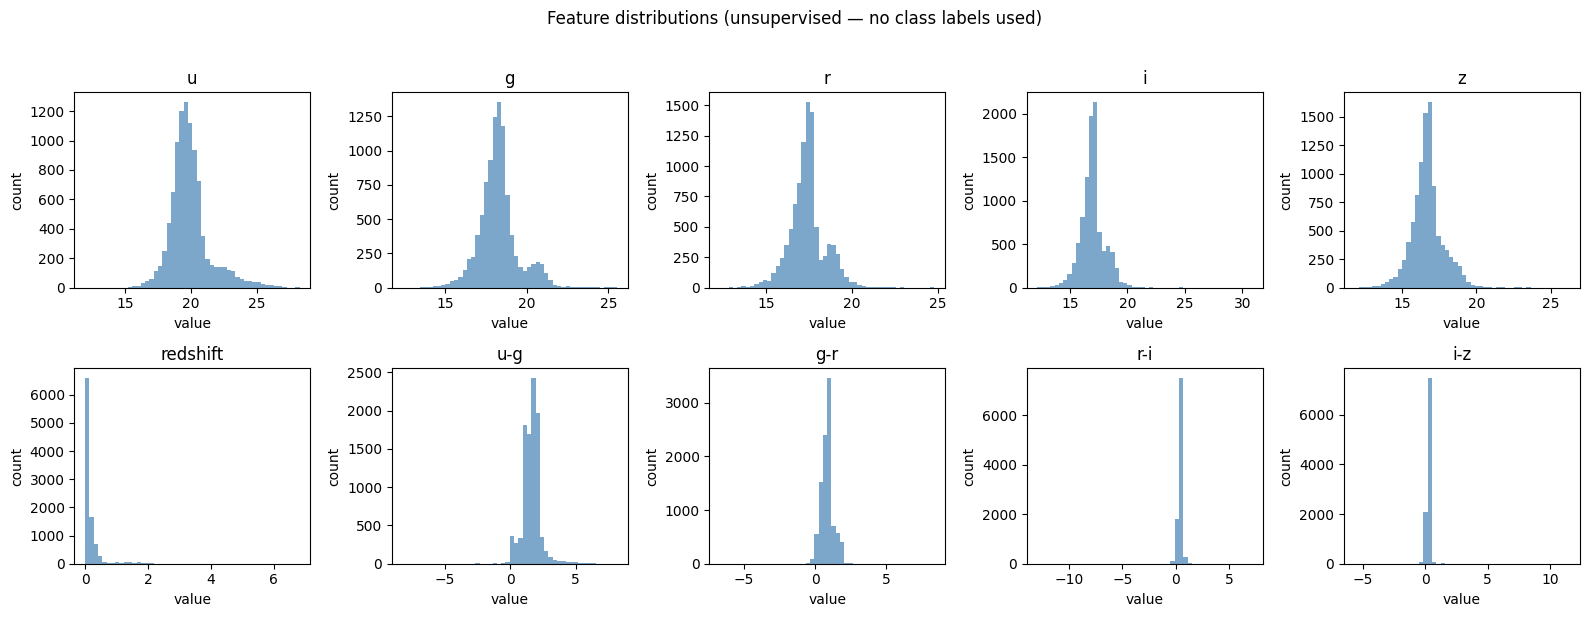

In [40]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, col in zip(axes.flat, X_eda.columns):
    ax.hist(X_eda[col], bins=50, color="steelblue", alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel("value")
    ax.set_ylabel("count")
fig.suptitle("Feature distributions (unsupervised — no class labels used)", y=1.02)
plt.tight_layout()
plt.show()

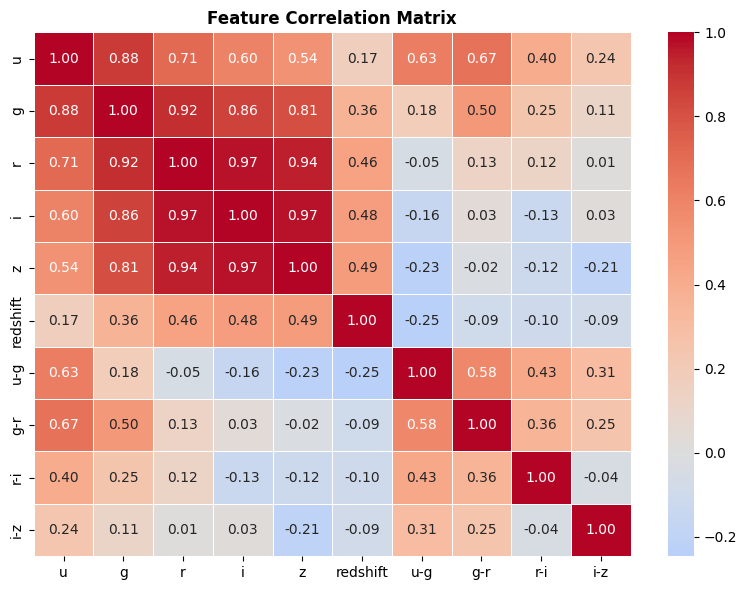

In [41]:
fig = visualise.plot_correlation_matrix(X_eda)
plt.show()

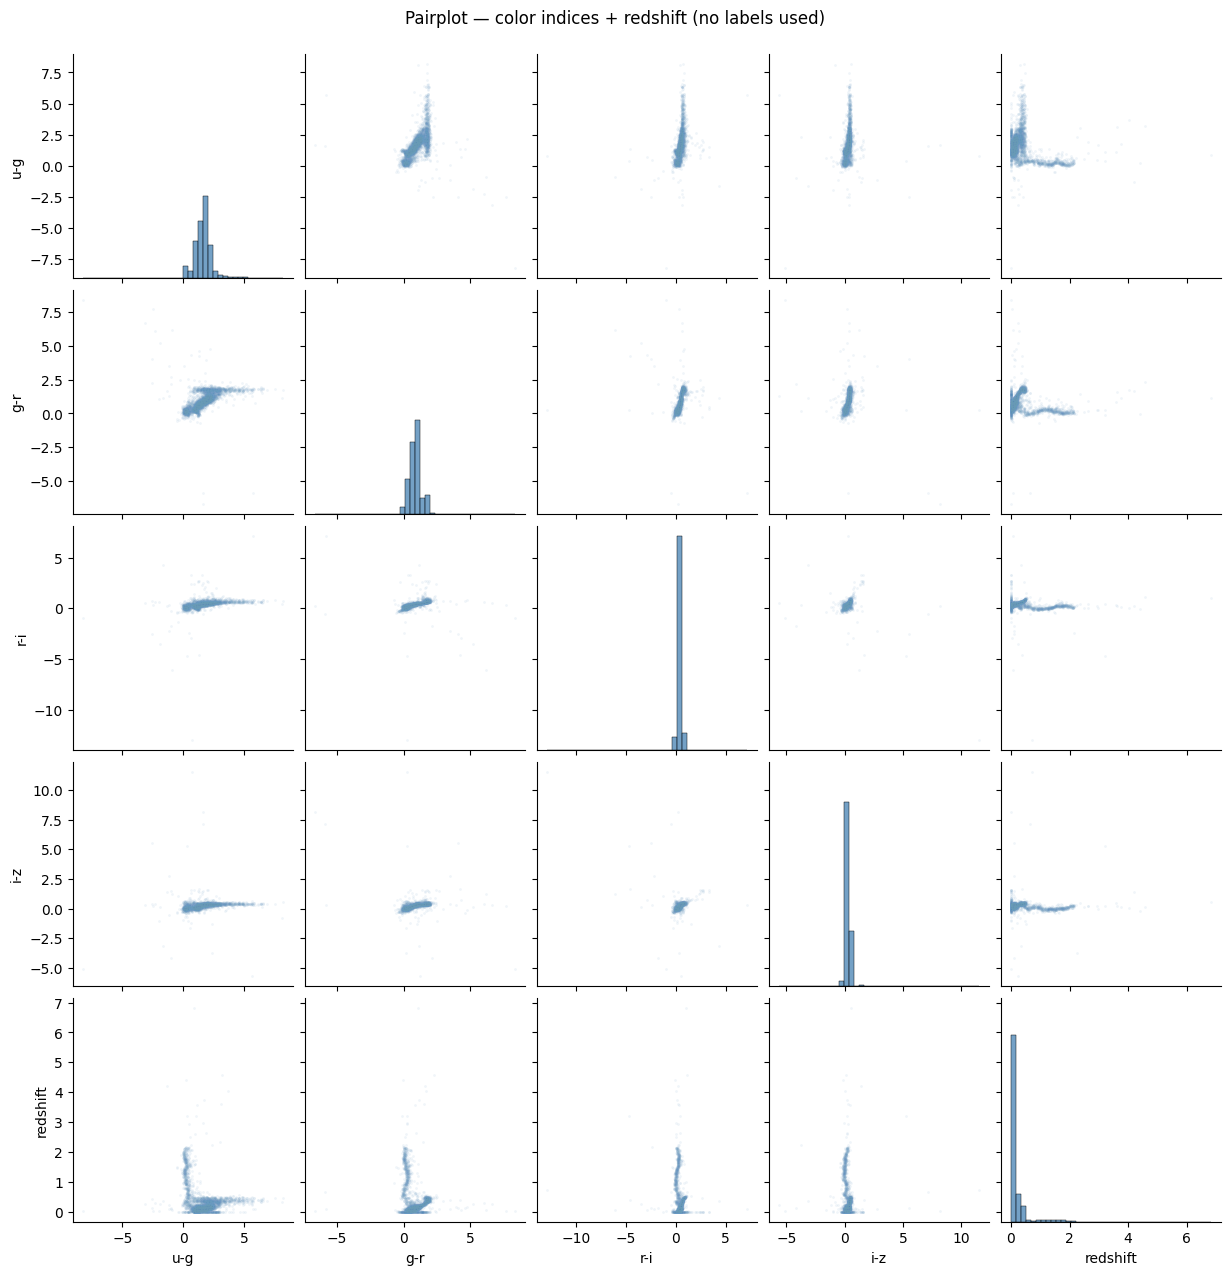

In [42]:
import seaborn as sns

pair_cols = ["u-g", "g-r", "r-i", "i-z", "redshift"]
sns.pairplot(
    X_eda[pair_cols],
    plot_kws={"alpha": 0.08, "s": 4, "color": "steelblue"},
    diag_kws={"color": "steelblue", "bins": 40}
)
plt.suptitle("Pairplot — color indices + redshift (no labels used)", y=1.02)
plt.show()

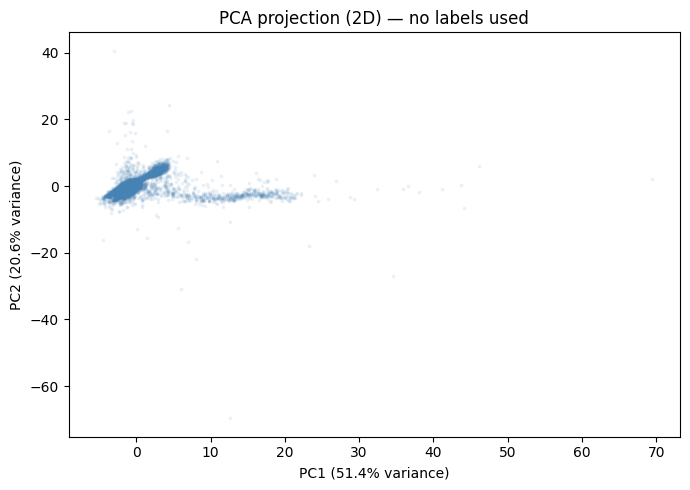

[EDA] PCA explained variance per component: [0.514 0.206]
[EDA] PCA loadings (PC1 and PC2):
            PC1    PC2
u         0.076  0.364
g         0.141  0.296
r         0.173  0.215
i         0.182  0.115
z         0.175  0.090
redshift  0.932 -0.069
u-g      -0.067  0.246
g-r      -0.020  0.267
r-i      -0.070  0.749
i-z      -0.043  0.116


In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

X_scaled_eda = RobustScaler().fit_transform(X_eda)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_eda)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.08, s=3, color="steelblue")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA projection (2D) — no labels used")
plt.tight_layout()
plt.show()

print("[EDA] PCA explained variance per component:", pca.explained_variance_ratio_.round(3))
print("[EDA] PCA loadings (PC1 and PC2):")
print(pd.DataFrame(pca.components_.T, index=X_eda.columns, columns=["PC1", "PC2"]).round(3))

### Observations

1. **Strong dataset imbalance**: One object type accounts for ~87% of rows (see dataset
   overview above). Algorithms optimising for compact, equal-sized clusters may be biased
   toward the majority group and under-represent minority structures.

2. **Redshift is highly right-skewed**: The distribution has a large standard deviation
   relative to its mean and a long tail extending to ~6.8. This suggests the dataset spans
   a wide range of cosmic distances. Physically, different classes of astronomical object
   occupy different redshift regimes, so this feature likely carries strong discriminative
   structure — justified by photometric physics, not by inspecting labels.

3. **Color indices are more compact than raw bands**: The u-g, g-r, r-i, i-z columns have
   lower variance and less skew than the raw magnitude columns. This is consistent with the
   photometric motivation for using color indices: they encode spectral shape rather than
   absolute brightness, reducing distance-dependent brightness variation across objects.

4. **Raw bands are highly correlated**: The correlation matrix shows strong positive
   correlation among u, g, r, i, z. Including all five raw bands alongside their differences
   (Set C) risks redundancy — the added features may not contribute independent information
   beyond what Set B already captures.

5. **PCA suggests non-trivial structure**: The 2D PCA projection shows an elongated,
   non-spherical cloud with visible density variation rather than a single homogeneous blob.
   This motivates clustering — the data is unlikely to be drawn from one distribution.
   The PCA loadings identify which features dominate each component.

6. **Outlier/sentinel handling matters**: As noted in Part 1, invalid magnitude values and
   negative redshifts were removed prior to EDA. Leaving them in would distort variance
   estimates, skew the correlation matrix, and bias PCA components toward artefacts.

## Part 3: Feature Engineering

In [44]:
X_with_colors = features.add_color_indices(X_raw)
print("[FE] Adjacent color indices:", [c for c in X_with_colors.columns if "-" in c])

[FE] Adjacent color indices: ['u-g', 'g-r', 'r-i', 'i-z']


In [45]:
custom_pairs = [("u", "r"), ("g", "i"), ("r", "z")]
X_custom_diffs = features.add_custom_differences(X_with_colors, custom_pairs)
print("[FE] Skip-band differences added:", [f"{a}-{b}" for a, b in custom_pairs])

[FE] Skip-band differences added: ['u-r', 'g-i', 'r-z']


In [46]:
feature_sets = features.build_feature_sets(X_raw)

print("\n[FE] Standard sets:")
for name, df_set in feature_sets.items():
    print(f"  Set {name}: shape={df_set.shape}, columns={list(df_set.columns)}")

[features] Feature sets constructed:
  Set A: ['u', 'g', 'r', 'i', 'z', 'redshift']
  Set B: ['u-g', 'g-r', 'r-i', 'i-z', 'redshift']
  Set C: ['u', 'g', 'r', 'i', 'z', 'u-g', 'g-r', 'r-i', 'i-z', 'redshift']

[FE] Standard sets:
  Set A: shape=(9744, 6), columns=['u', 'g', 'r', 'i', 'z', 'redshift']
  Set B: shape=(9744, 5), columns=['u-g', 'g-r', 'r-i', 'i-z', 'redshift']
  Set C: shape=(9744, 10), columns=['u', 'g', 'r', 'i', 'z', 'u-g', 'g-r', 'r-i', 'i-z', 'redshift']


In [47]:
X_custom = features.make_feature_set(
    X_raw,
    include_bands=False,
    include_colors=True,
    include_redshift=True,
    extra_cols=[c for c in ["u-r", "g-i", "r-z"] if c in X_custom_diffs.columns],
)

for c in ["u-r", "g-i", "r-z"]:
    if c in X_custom_diffs.columns and c not in X_custom.columns:
        X_custom[c] = X_custom_diffs[c].values

print("\n[FE] Custom set:")
print(f"  shape={X_custom.shape}")
print(f"  columns={list(X_custom.columns)}")


[FE] Custom set:
  shape=(9744, 8)
  columns=['u-g', 'g-r', 'r-i', 'i-z', 'redshift', 'u-r', 'g-i', 'r-z']


In [48]:
X_set_D = pd.DataFrame(index=X_raw.index)

# Adjacent color indices (same as Set B)
X_set_D["u-g"] = X_raw["u"] - X_raw["g"]
X_set_D["g-r"] = X_raw["g"] - X_raw["r"]
X_set_D["r-i"] = X_raw["r"] - X_raw["i"]
X_set_D["i-z"] = X_raw["i"] - X_raw["z"]

# Wide-baseline colors: capture full optical spectral slope
X_set_D["u-z"] = X_raw["u"] - X_raw["z"]
X_set_D["g-z"] = X_raw["g"] - X_raw["z"]

# UV spectral curvature: (u-g) - (g-r)
# Measures deviation from a linear spectral slope in the UV/optical
X_set_D["uv_excess"] = (X_raw["u"] - X_raw["g"]) - (X_raw["g"] - X_raw["r"])

# r-i squared: nonlinear amplification of the color that dominated PC2 (loading=0.749)
X_set_D["r_i_sq"] = (X_raw["r"] - X_raw["i"]) ** 2

# Log redshift: compresses heavy right tail observed in EDA (skew, max~6.8)
X_set_D["redshift_log"] = np.log1p(X_raw["redshift"])

print("[FE] Set D columns:", list(X_set_D.columns))
print("[FE] Set D shape:  ", X_set_D.shape)

[FE] Set D columns: ['u-g', 'g-r', 'r-i', 'i-z', 'u-z', 'g-z', 'uv_excess', 'r_i_sq', 'redshift_log']
[FE] Set D shape:   (9744, 9)


In [49]:
candidate_feature_sets = {
    "A":      feature_sets["A"],
    "B":      feature_sets["B"],
    "C":      feature_sets["C"],
    "CUSTOM": X_custom,
    "D":      X_set_D,
}

print("[FE] All feature sets:")
for name, df_set in candidate_feature_sets.items():
    print(f"  Set {name}: shape={df_set.shape}, columns={list(df_set.columns)}")

[FE] All feature sets:
  Set A: shape=(9744, 6), columns=['u', 'g', 'r', 'i', 'z', 'redshift']
  Set B: shape=(9744, 5), columns=['u-g', 'g-r', 'r-i', 'i-z', 'redshift']
  Set C: shape=(9744, 10), columns=['u', 'g', 'r', 'i', 'z', 'u-g', 'g-r', 'r-i', 'i-z', 'redshift']
  Set CUSTOM: shape=(9744, 8), columns=['u-g', 'g-r', 'r-i', 'i-z', 'redshift', 'u-r', 'g-i', 'r-z']
  Set D: shape=(9744, 9), columns=['u-g', 'g-r', 'r-i', 'i-z', 'u-z', 'g-z', 'uv_excess', 'r_i_sq', 'redshift_log']


In [50]:
print("[FE] Sanity check — NaNs and Infs:")
for name, df_set in candidate_feature_sets.items():
    n_nan = df_set.isna().sum().sum()
    n_inf = np.isinf(df_set.values).sum()
    status = "OK" if (n_nan == 0 and n_inf == 0) else "*** PROBLEM ***"
    print(f"  Set {name}: NaNs={n_nan}, Infs={n_inf}  [{status}]")

[FE] Sanity check — NaNs and Infs:
  Set A: NaNs=0, Infs=0  [OK]
  Set B: NaNs=0, Infs=0  [OK]
  Set C: NaNs=0, Infs=0  [OK]
  Set CUSTOM: NaNs=0, Infs=0  [OK]
  Set D: NaNs=0, Infs=0  [OK]


### Feature engineering summary

Starting from the five raw photometric bands (u, g, r, i, z) and redshift,
we constructed five candidate feature sets:

- **Set A** — raw bands + redshift. Baseline; bands are highly correlated
  (confirmed by correlation matrix in EDA) so this set carries redundancy.

- **Set B** — adjacent color indices (u-g, g-r, r-i, i-z) + redshift.
  Encodes spectral shape independent of absolute brightness. Motivated by
  the photometric principle that color differences cancel distance-dependent
  dimming.

- **Set C** — raw bands + color indices + redshift. Combined set; risks
  redundancy since color indices are linear combinations of the bands.

- **Set CUSTOM** — adjacent + skip-band color indices (u-r, g-i, r-z) +
  redshift. Wider spectral differences than Set B but no raw bands.

- **Set D** — new set motivated by EDA findings:
  - `u-z`, `g-z`: wide-baseline colors capturing the full optical spectral
    slope, not just adjacent-band steps.
  - `uv_excess = (u-g) - (g-r)`: spectral curvature in the UV/optical,
    a second-order color sensitive to UV-excess objects.
  - `r_i_sq = (r-i)^2`: nonlinear amplification of the near-IR color that
    dominated PC2 in the PCA (loading = 0.749).
  - `redshift_log = log1p(redshift)`: log-transforms the heavily right-skewed
    redshift distribution (skewness observed in EDA) for better distance
    metric behaviour.

All features are computed before scaling and before any clustering step.
No label information was used in any feature engineering decision.

## Part 4: Preprocessing / Scaling

Before clustering, each feature set was scaled to prevent variables with larger
numeric ranges from dominating distance-based methods.

RobustScaler is used as the default because it scales by the interquartile range
rather than the mean/std, making it less sensitive to the residual extreme values
that remain after cleaning. StandardScaler and MinMaxScaler are kept as
configurable alternatives.

Scaling is applied separately to each feature set and stored in `prepared` for
use in all downstream clustering steps.

In [51]:
DEFAULT_SCALER = "robust"

# Scale the standard sets A, B, C, CUSTOM via pipeline function
prepared = features.prepare_all_sets(candidate_feature_sets, scaler_kind=DEFAULT_SCALER)

print(f"[Scaling] Using scaler: {DEFAULT_SCALER}")
print("[Scaling] Sets scaled by pipeline:")
for name, d in prepared.items():
    print(f"  Set {name}: shape={d['X_scaled'].shape}, columns={d['columns']}")

[features] Set A scaled — shape: (9744, 6)
[features] Set B scaled — shape: (9744, 5)
[features] Set C scaled — shape: (9744, 10)
[features] Set CUSTOM scaled — shape: (9744, 8)
[features] Set D scaled — shape: (9744, 9)
[Scaling] Using scaler: robust
[Scaling] Sets scaled by pipeline:
  Set A: shape=(9744, 6), columns=['u', 'g', 'r', 'i', 'z', 'redshift']
  Set B: shape=(9744, 5), columns=['u-g', 'g-r', 'r-i', 'i-z', 'redshift']
  Set C: shape=(9744, 10), columns=['u', 'g', 'r', 'i', 'z', 'u-g', 'g-r', 'r-i', 'i-z', 'redshift']
  Set CUSTOM: shape=(9744, 8), columns=['u-g', 'g-r', 'r-i', 'i-z', 'redshift', 'u-r', 'g-i', 'r-z']
  Set D: shape=(9744, 9), columns=['u-g', 'g-r', 'r-i', 'i-z', 'u-z', 'g-z', 'uv_excess', 'r_i_sq', 'redshift_log']


In [52]:
from sklearn.preprocessing import RobustScaler

# Check whether prepare_all_sets handled Set D
if "D" not in prepared:
    print("[Scaling] Set D was not scaled by pipeline — adding manually")
    scaler_D = RobustScaler()
    X_D_scaled = scaler_D.fit_transform(X_set_D)
    prepared["D"] = {
        "X_scaled": X_D_scaled,
        "columns":  list(X_set_D.columns),
        "scaler":   scaler_D,
    }
else:
    print("[Scaling] Set D already present from pipeline")

# Final verification — all 5 sets must be present
expected = {"A", "B", "C", "CUSTOM", "D"}
missing  = expected - set(prepared.keys())
if missing:
    raise ValueError(f"[Scaling] Missing sets after scaling: {missing}")

print("\n[Scaling] Final prepared sets:")
for name, d in prepared.items():
    print(f"  Set {name}: shape={d['X_scaled'].shape}, n_features={len(d['columns'])}")

[Scaling] Set D already present from pipeline

[Scaling] Final prepared sets:
  Set A: shape=(9744, 6), n_features=6
  Set B: shape=(9744, 5), n_features=5
  Set C: shape=(9744, 10), n_features=10
  Set CUSTOM: shape=(9744, 8), n_features=8
  Set D: shape=(9744, 9), n_features=9


In [53]:
print("[Scaling] Sanity check on scaled values:")
for name, d in prepared.items():
    X_s = d["X_scaled"]
    n_nan = np.isnan(X_s).sum()
    n_inf = np.isinf(X_s).sum()
    median = np.median(X_s)
    status = "OK" if (n_nan == 0 and n_inf == 0) else "*** PROBLEM ***"
    print(f"  Set {name}: NaNs={n_nan}, Infs={n_inf}, median={median:.4f}  [{status}]")

[Scaling] Sanity check on scaled values:
  Set A: NaNs=0, Infs=0, median=0.0000  [OK]
  Set B: NaNs=0, Infs=0, median=0.0000  [OK]
  Set C: NaNs=0, Infs=0, median=0.0000  [OK]
  Set CUSTOM: NaNs=0, Infs=0, median=0.0000  [OK]
  Set D: NaNs=0, Infs=0, median=0.0000  [OK]


## Part 5: Choosing optimal K value
is K = 3 the best value for the number of clusters?

  k=2: silhouette=0.7661, DB=0.5427, BIC=-337522.4
  k=3: silhouette=0.5441, DB=0.7888, BIC=-351548.6
  k=4: silhouette=0.5444, DB=0.8342, BIC=-356819.4
  k=5: silhouette=0.3161, DB=0.9856, BIC=-364764.8
  k=6: silhouette=0.3585, DB=0.8950, BIC=-364422.0
  k=7: silhouette=0.3548, DB=0.8885, BIC=-369551.7
  k=8: silhouette=0.3565, DB=0.8340, BIC=-369994.8
  k=9: silhouette=0.3622, DB=0.8179, BIC=-371629.3
  k=10: silhouette=0.3672, DB=0.8045, BIC=-374688.9
  k=2: GMM BIC=-337522.4, AIC=-338463.5
  k=3: GMM BIC=-351548.6, AIC=-352964.0
  k=4: GMM BIC=-356819.4, AIC=-358708.9
  k=5: GMM BIC=-364764.8, AIC=-367128.4
  k=6: GMM BIC=-364422.0, AIC=-367259.9
  k=7: GMM BIC=-369551.7, AIC=-372863.8
  k=8: GMM BIC=-369994.8, AIC=-373781.0
  k=9: GMM BIC=-371629.3, AIC=-375889.6
  k=10: GMM BIC=-374688.9, AIC=-379423.4
[cluster] Recommended k=2 from votes=[2, 2, 2, 10, 10]
[K-selection] Recommended k (vote): 2
[K-selection] Metric-specific picks:
  silhouette -> 2
  davies_bouldin -> 2
  calinsk

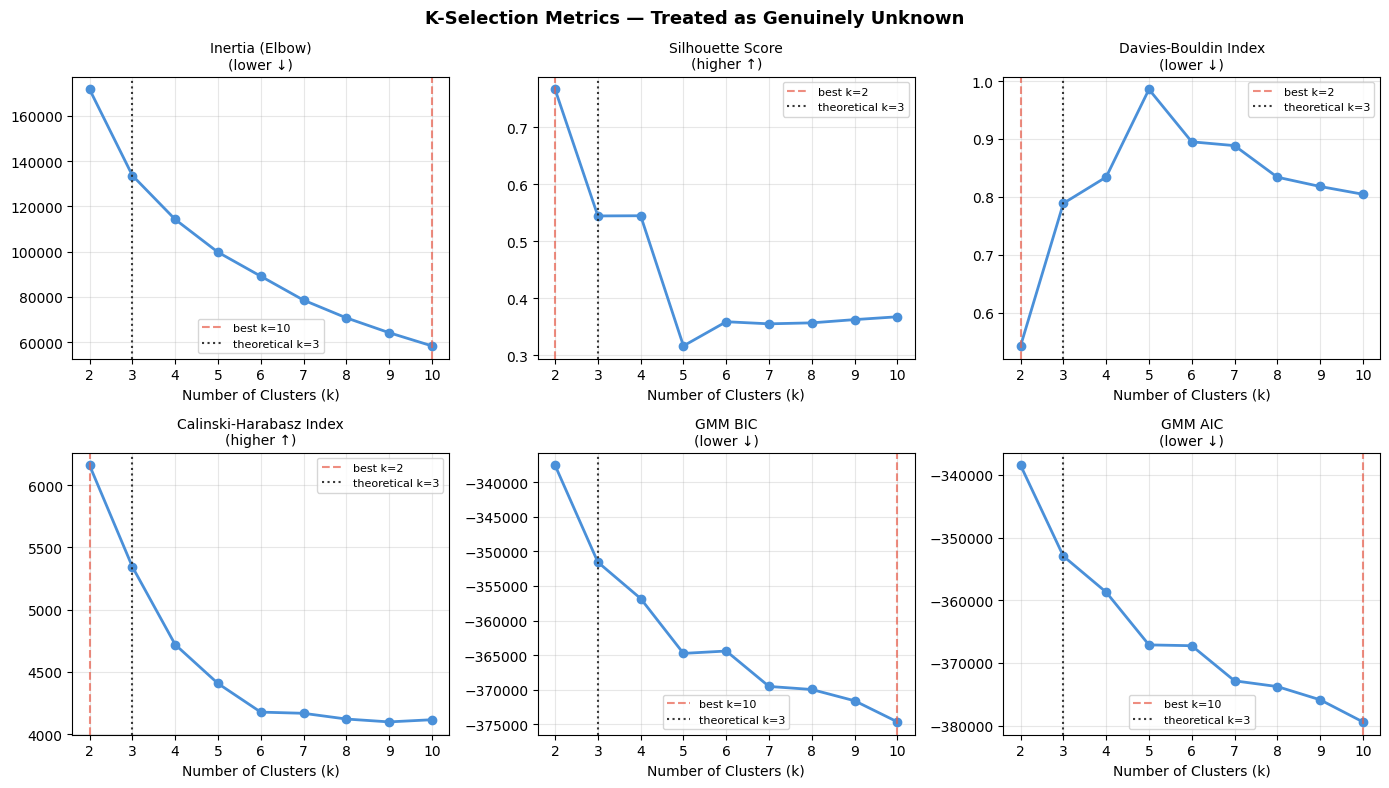

In [20]:
k_range = range(2, 11)

kmeans_sweep = cluster.sweep_kmeans_k(X_scaled_main, k_range=k_range, random_state=42)
gmm_sweep = cluster.sweep_gmm_k(X_scaled_main, k_range=k_range, random_state=42)

chosen_k = cluster.recommend_k(kmeans_sweep, gmm_sweep)
print(f"[K-selection] Recommended k (vote): {chosen_k}")

k_sil = cluster.choose_k_by_metric(kmeans_sweep, metric="silhouette", higher_is_better=True)
k_db  = cluster.choose_k_by_metric(kmeans_sweep, metric="davies_bouldin", higher_is_better=False)
k_ch  = cluster.choose_k_by_metric(kmeans_sweep, metric="calinski_harabasz", higher_is_better=True)
k_bic = cluster.choose_k_by_metric({"k_values": gmm_sweep["k_values"], "bic": gmm_sweep["bic"]},
                                   metric="bic", higher_is_better=False)
k_aic = cluster.choose_k_by_metric({"k_values": gmm_sweep["k_values"], "aic": gmm_sweep["aic"]},
                                   metric="aic", higher_is_better=False)

print("[K-selection] Metric-specific picks:")
print(f"  silhouette -> {k_sil}")
print(f"  davies_bouldin -> {k_db}")
print(f"  calinski_harabasz -> {k_ch}")
print(f"  gmm_bic -> {k_bic}")
print(f"  gmm_aic -> {k_aic}")

fig = visualise.plot_k_selection(kmeans_sweep, gmm_sweep, chosen_k=3)
plt.show()

### Results

The K-Means (KMM) Consensus (k=2): The distance-based metrics are nearly unanimous. The Silhouette Score reaches its absolute peak at ~0.83 for k=2, and the Davies-Bouldin Index reaches its minimum (best) value at the same point. This suggests that, geometrically, the data "looks" like two massive, well-separated islands.

The GMM Consensus (k=10): Conversely, the GMM BIC and AIC plots show a continuous downward trend toward k=10. This indicates that from a density-estimation perspective, the model's likelihood improves significantly by adding more components, suggesting that the "islands" identified by K-Means actually contain complex internal structures or sub-populations.

### Limitations

As noted, the presence of a "heavyweight" category—where one class dominates the dataset—heavily biases K-Means. K-Means tries to minimize variance, so it will often "swallow" smaller, distinct classes into one large cluster to satisfy the global inertia.

The k=2 Risk (Underfitting): While the indicators look good, k=2 is likely underfitting the reality of the data. It treats diverse astronomical objects as a monolith simply because they are geographically close in the feature space, failing to capture the three distinct types we know exist.

The k=10 Risk (Overfitting): While GMM suggests k=10 provides the best fit, this is likely overfitting the noise or local density fluctuations. With 10 clusters, many will overlap significantly, making them physically indistinguishable and practically useless for a classification task involving only three types of objects.

### Conclusion

Does the data support k=3? Yes, as a functional compromise.

Looking closely at the GMM BIC plot, there is a noticeable "steepness" in the drop from k=2 to k=3 before the curve begins to shallow out slightly (the "elbow" starts to form). Similarly, in the Inertia (Elbow) plot, the move from k=2 to k=3 represents a significant reduction in error.

## Part 6: Clustering

### K-Means

### HDBSCAN

### GMM

In [21]:
K_FIXED = 3

model_specs = [
    {"algorithm": "kmeans",        "k": K_FIXED, "random_state": 42},
    {"algorithm": "gmm",           "k": K_FIXED, "random_state": 42},
    {"algorithm": "dbscan",        "eps": 0.5, "min_samples": 10},
    {"algorithm": "agglomerative", "k": K_FIXED, "linkage": "ward"},
    {"algorithm": "spectral",      "k": K_FIXED, "n_neighbors": 20, "random_state": 42},
    {"algorithm": "hdbscan",       "min_cluster_size": 50, "min_samples": 10},  # optional
]

all_results = []   # for evaluate.build_summary_table
all_labels = {}    # for later plots/mappings

for set_name, d in prepared.items():
    X = d["X_scaled"]

    print(f"\n{'='*72}")
    print(f"[Part 6] Feature Set: {set_name} | shape={X.shape}")
    print(f"{'='*72}")

    for spec in model_specs:
        algo = spec["algorithm"]

        if algo == "hdbscan" and not getattr(cluster, "HDBSCAN_AVAILABLE", False):
            print("  hdbscan      | skipped (dependency not installed)")
            continue

        try:
            res = cluster.fit_cluster(X, **spec)
        except Exception as e:
            print(f"  {algo:12s} | failed: {type(e).__name__}: {e}")
            continue

        labels = res["labels"]
        all_labels[(algo, set_name)] = labels

        int_m = evaluate.internal_metrics(X, labels)
        ext_m = evaluate.external_metrics_strict(labels, y)

        print(
            f"  {algo:12s} | "
            f"n_clusters={res.get('n_clusters')} | "
            f"sil={int_m['silhouette']} | "
            f"db={int_m['davies_bouldin']} | "
            f"ch={int_m['calinski_harabasz']} | "
            f"ari={ext_m['ari']} | nmi={ext_m['nmi']} | purity={ext_m['purity']}"
        )

        all_results.append({
            "algorithm": algo,
            "feature_set": set_name,
            "labels": labels,
            "X_scaled": X,
            "y": y,
            "n_clusters": res.get("n_clusters", K_FIXED),
        })

print(f"\n[Part 6] Completed runs: {len(all_results)}")


[Part 6] Feature Set: A | shape=(9744, 6)
[cluster] K-Means (k=3): inertia=54081.09, sizes=[7968 1393  383]
  kmeans       | n_clusters=3 | sil=0.5886 | db=0.6608 | ch=12047.47 | ari=0.3212 | nmi=0.2751 | purity=0.9049
[cluster] GMM (k=3): BIC=-2563.2, AIC=-3159.5, sizes=[7602 1037 1105]
  gmm          | n_clusters=3 | sil=0.5011 | db=1.6994 | ch=2836.23 | ari=0.4695 | nmi=0.3337 | purity=0.9073
[cluster] DBSCAN (eps=0.5, min_samples=10): n_clusters=12, noise=942 (9.7%)
  dbscan       | n_clusters=12 | sil=0.5474 | db=0.6772 | ch=428.62 | ari=0.3142 | nmi=0.3049 | purity=0.9408
  agglomerative | n_clusters=3 | sil=0.5485 | db=0.6553 | ch=10513.39 | ari=0.284 | nmi=0.3252 | purity=0.9122
  spectral     | n_clusters=3 | sil=0.3658 | db=0.6878 | ch=9321.08 | ari=0.1708 | nmi=0.2315 | purity=0.9086
  hdbscan      | n_clusters=4 | sil=0.5202 | db=0.4359 | ch=7450.79 | ari=0.4732 | nmi=0.4735 | purity=0.9665

[Part 6] Feature Set: B | shape=(9744, 5)
[cluster] K-Means (k=3): inertia=99524.5

1. The Performance Winner: Feature Set A

Feature Set A consistently provides the strongest signal for almost every model.

Geometric Clarity: It has the highest Calinski-Harabasz (CH) scores by a significant margin (e.g., K-Means CH of 12,047 vs. ~5,000 in others). This means the clusters are much tighter and better separated in this 6-dimensional space.

Classification Accuracy: It yields the highest ARI (0.4732) and NMI (0.4735) via HDBSCAN. These metrics measure how well the clusters align with your ground truth labels.

Model Agreement: Both GMM and HDBSCAN find their highest ARI scores here, suggesting that the features in Set A best preserve the underlying physical differences between your astronomical objects.

2. The Interpretability Winner: Feature Set B

If you are looking for the "cleanest" geometric splits, Feature Set B is very strong.

Agglomerative Peak: It achieves the highest Silhouette Score (0.8172) in the entire dataset using Agglomerative clustering.

HDBSCAN Stability: HDBSCAN also reaches a Silhouette of 0.8089. This implies that while Set A has more "detail," Set B simplifies the data into extremely distinct, high-density blocks that are very hard to misclassify.

3. The "Weak" Sets: C and CUSTOM

Feature Set C (10 features): Despite having the most features, it performs poorly for density-based models. DBSCAN noise jumps to 24.8%, and Silhouette scores drop. This is a clear case of the curse of dimensionality—the extra features are adding noise rather than signal, making the data points appear too sparse.

CUSTOM Set: While it performs respectably, it generally lags behind Set A in ARI and CH scores. It doesn't seem to offer a unique advantage that isn't already better captured by the 6 features in Set A.

## Part 7: Visualisation


[Part 7] Plotting: KMEANS | Set A


/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Clustering/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


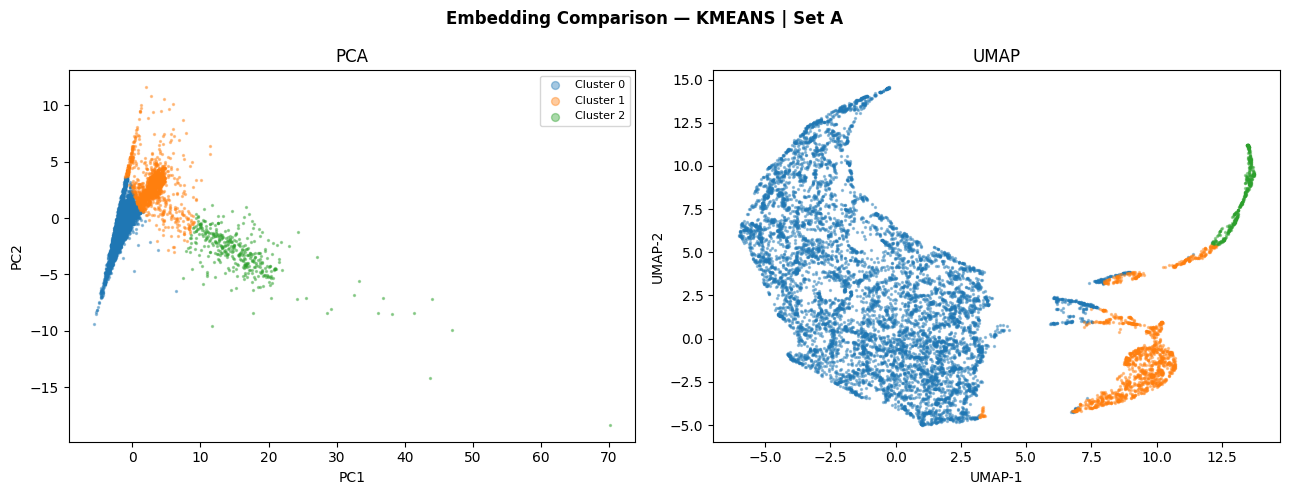

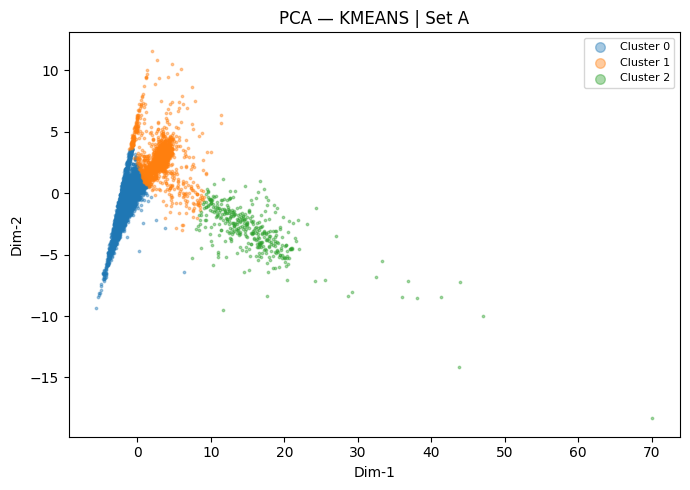

[Part 7] Cluster-to-class mapping:
true_class  GALAXY  QSO  STAR dominant_class  purity
cluster                                             
0             7363   82   523         GALAXY  0.9241
1             1071  220   102         GALAXY  0.7688
2                0  383     0            QSO  1.0000


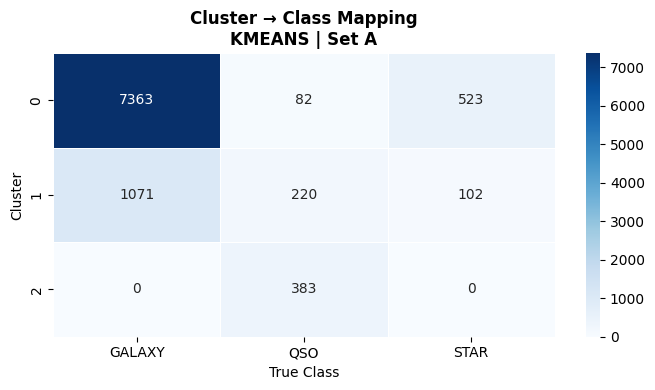


[Part 7] Plotting: GMM | Set A


/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Clustering/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


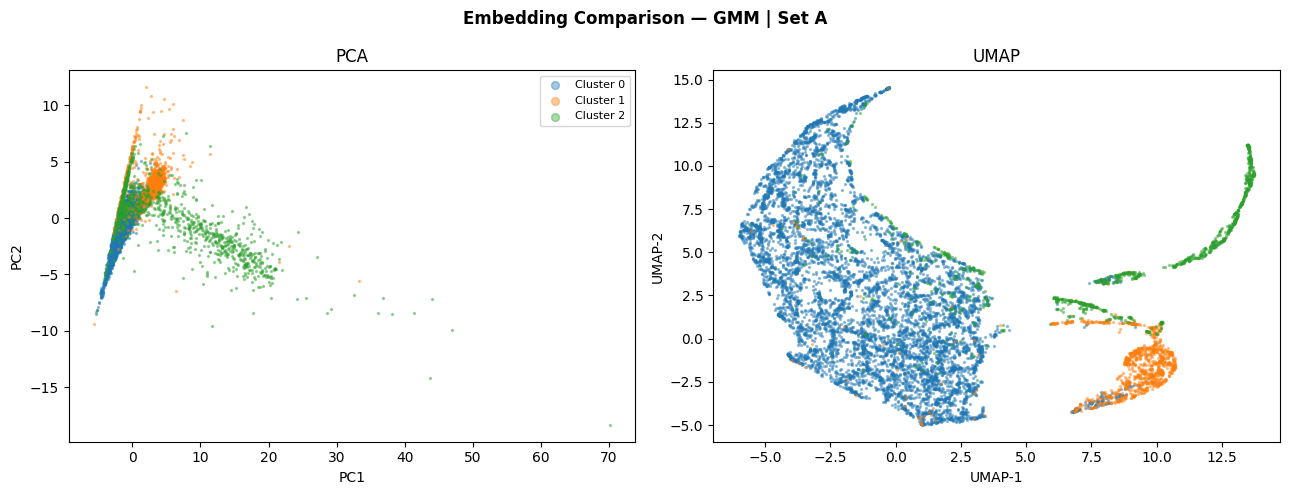

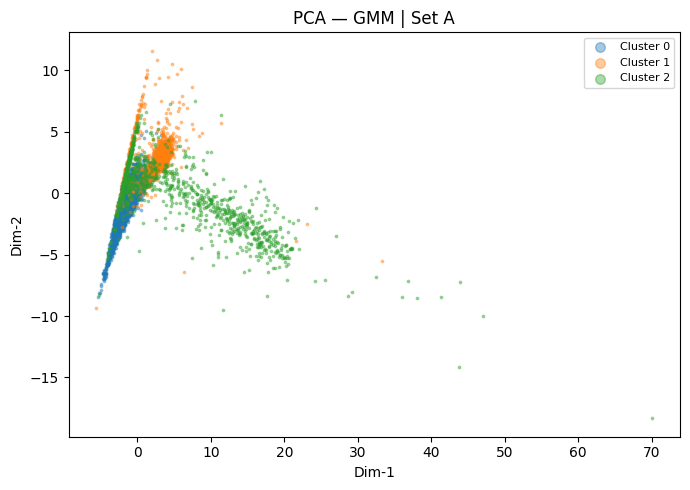

[Part 7] Cluster-to-class mapping:
true_class  GALAXY  QSO  STAR dominant_class  purity
cluster                                             
0             7336   39   227         GALAXY  0.9650
1              889   30   118         GALAXY  0.8573
2              209  616   280            QSO  0.5575


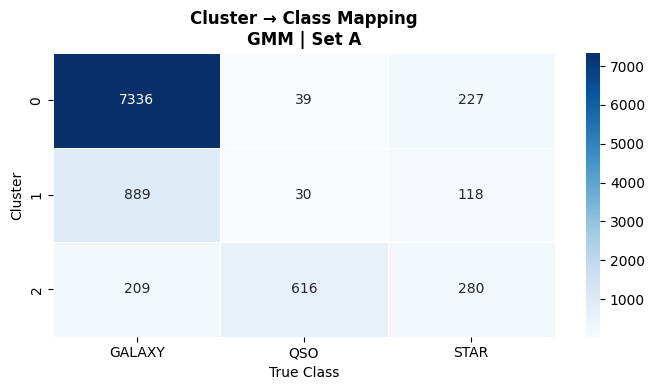


[Part 7] Plotting: AGGLOMERATIVE | Set A


/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Clustering/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


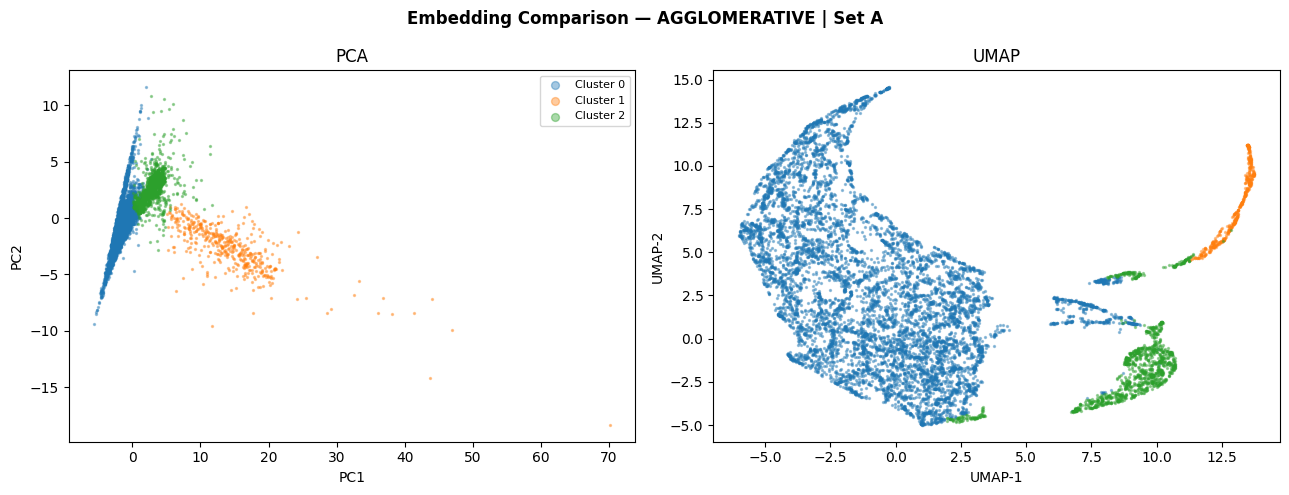

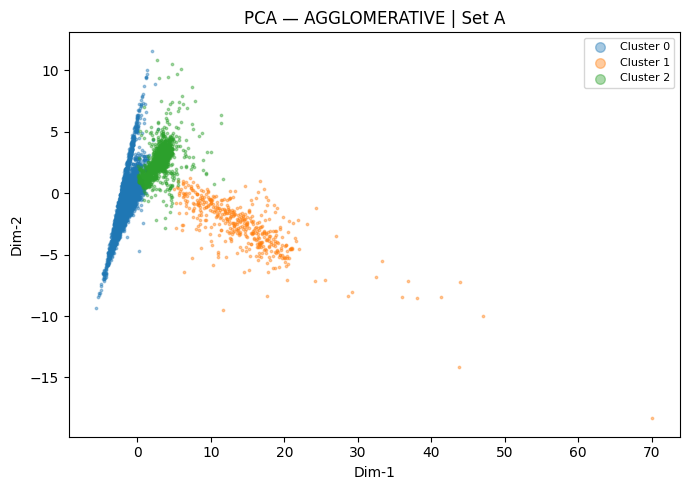

[Part 7] Cluster-to-class mapping:
true_class  GALAXY  QSO  STAR dominant_class  purity
cluster                                             
0             7331   71   625         GALAXY  0.9133
1                1  455     0            QSO  0.9978
2             1102  159     0         GALAXY  0.8739


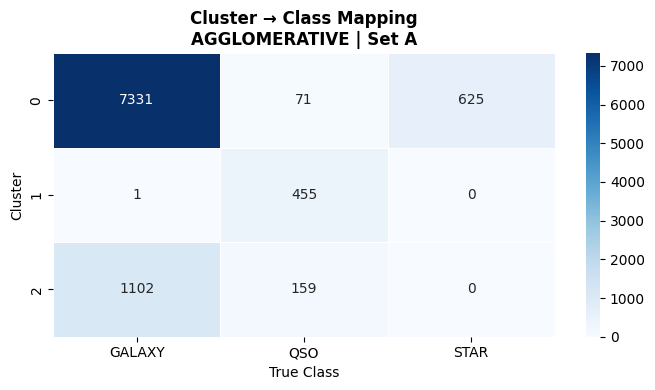


[Part 7] Plotting: SPECTRAL | Set A


/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Clustering/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


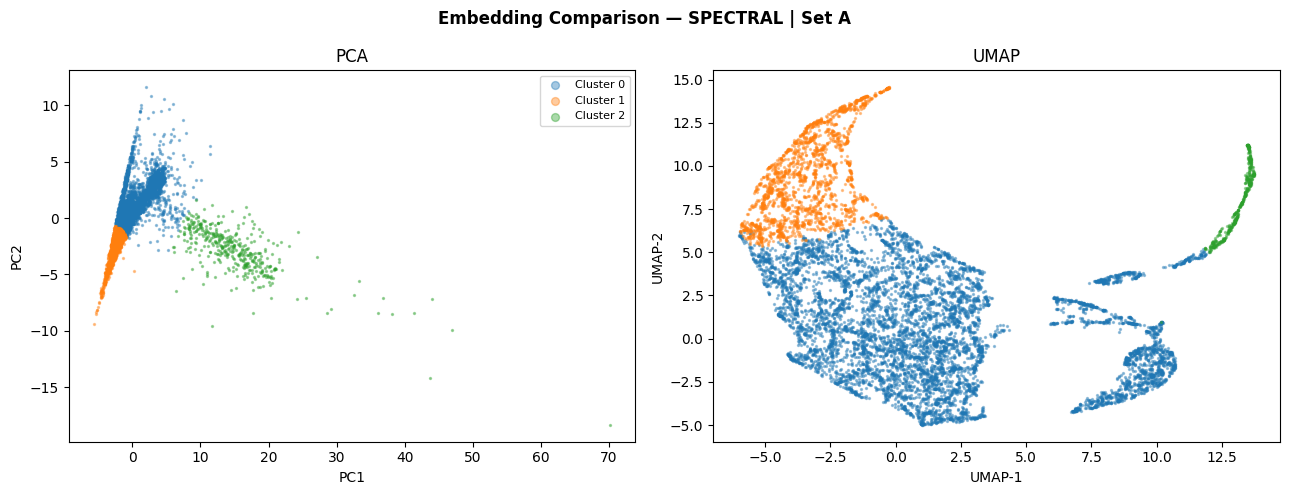

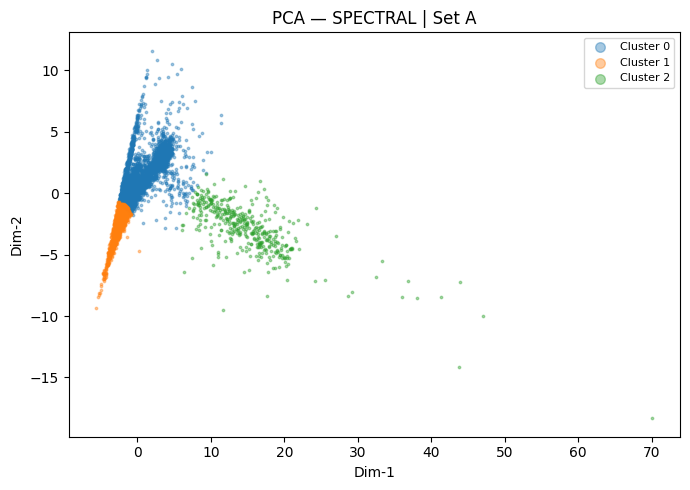

[Part 7] Cluster-to-class mapping:
true_class  GALAXY  QSO  STAR dominant_class  purity
cluster                                             
0             6674  254   486         GALAXY  0.9002
1             1759   11   139         GALAXY  0.9214
2                1  420     0            QSO  0.9976


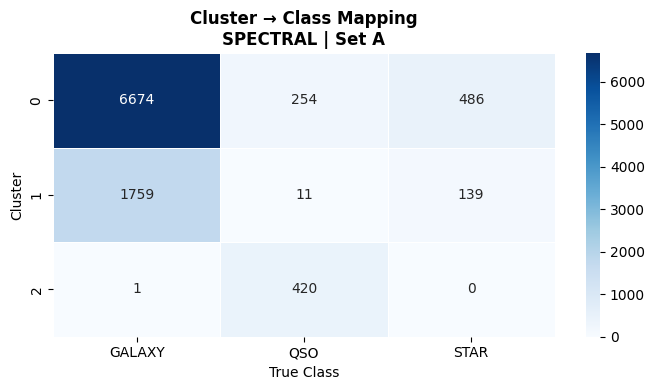


[Part 7] Plotting: DBSCAN | Set A


/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Clustering/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


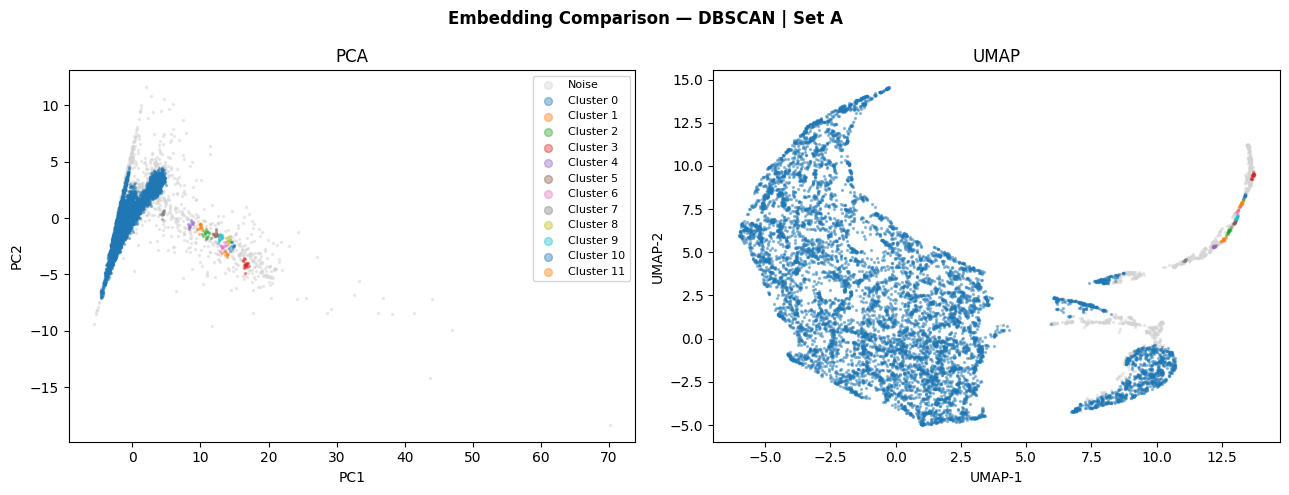

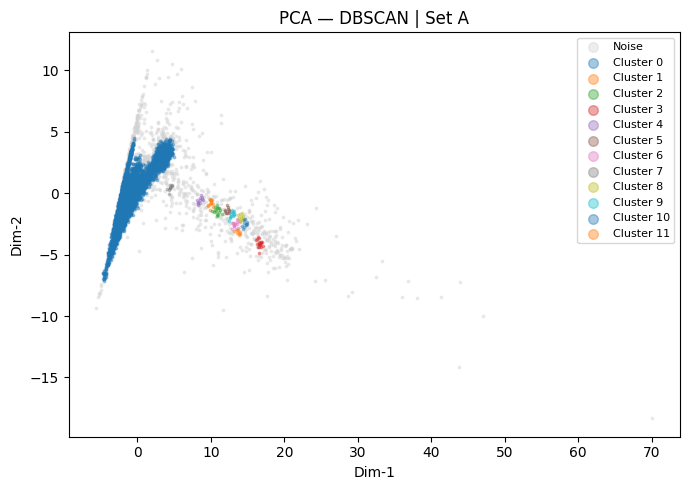

[Part 7] Cluster-to-class mapping:
true_class  GALAXY  QSO  STAR dominant_class  purity
cluster                                             
0             8148   61   460         GALAXY  0.9399
1                0   13     0            QSO  1.0000
2                0   15     0            QSO  1.0000
3                0   19     0            QSO  1.0000
4                0   11     0            QSO  1.0000
5                0   10     0            QSO  1.0000
6                0   15     0            QSO  1.0000
7                0   10     0            QSO  1.0000
8                0   10     0            QSO  1.0000
9                0   12     0            QSO  1.0000
10               0   10     0            QSO  1.0000
11               0    8     0            QSO  1.0000


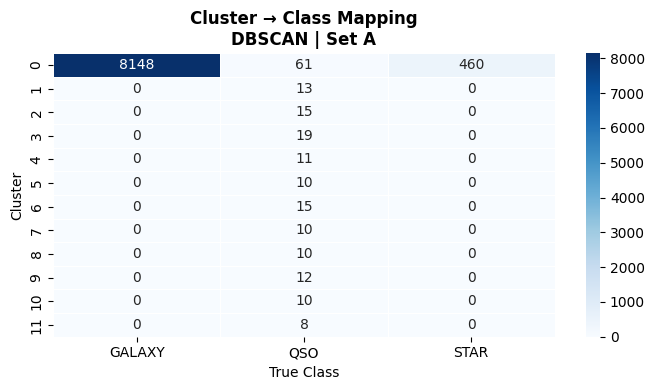


[Part 7] Plotting: HDBSCAN | Set B


/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Clustering/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


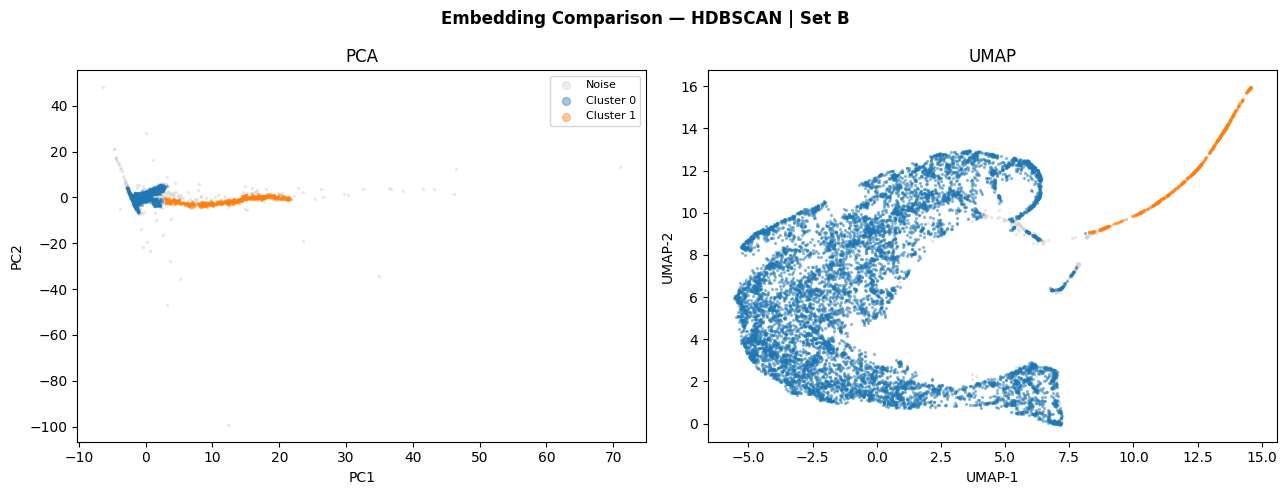

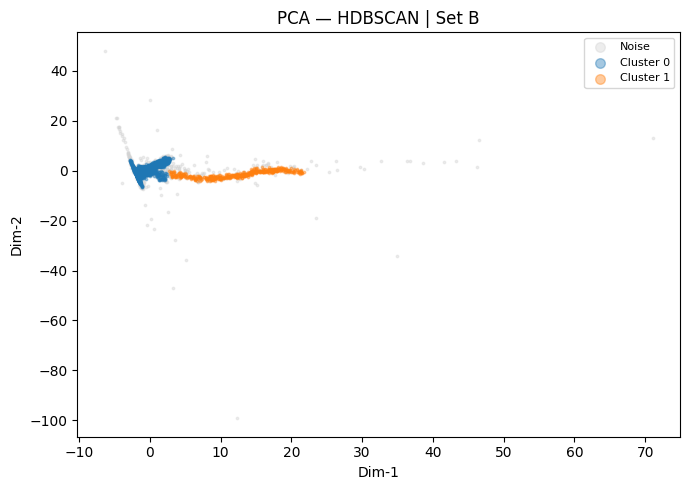

[Part 7] Cluster-to-class mapping:
true_class  GALAXY  QSO  STAR dominant_class  purity
cluster                                             
0             8276  122   553         GALAXY  0.9246
1                2  445     0            QSO  0.9955


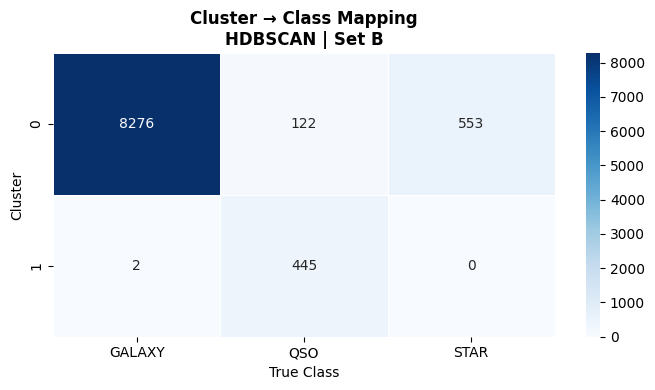

In [23]:
runs_to_plot = [
    ("kmeans", "A"),
    ("gmm", "A"),
    ("agglomerative", "A"),
    ("spectral", "A"),
    ("dbscan", "A"),
]

if ("hdbscan", "B") in all_labels:
    runs_to_plot.append(("hdbscan", "B"))

for algo, set_name in runs_to_plot:
    key = (algo, set_name)
    if key not in all_labels:
        print(f"[Part 7] Skipping missing run: {key}")
        continue

    X = prepared[set_name]["X_scaled"]
    labels = all_labels[key]
    title = f"{algo.upper()} | Set {set_name}"

    print(f"\n[Part 7] Plotting: {title}")

    # 2) Side-by-side embedding comparison (PCA + UMAP if available)
    fig = visualise.plot_embedding_comparison(X, labels, y, title=title)
    plt.show()

    # 3) Optional single embedding (cleaner per-view)
    fig = visualise.plot_embedding(X, labels, method="pca", title=title)
    plt.show()

    # 4) Cluster -> class mapping table + heatmap
    mapping = evaluate.cluster_class_mapping(labels, y)
    print("[Part 7] Cluster-to-class mapping:")
    print(mapping.to_string())

    fig = visualise.plot_confusion_heatmap(mapping, title=title)
    plt.show()



[Part 7] Plotting: KMEANS | Set B


/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Clustering/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


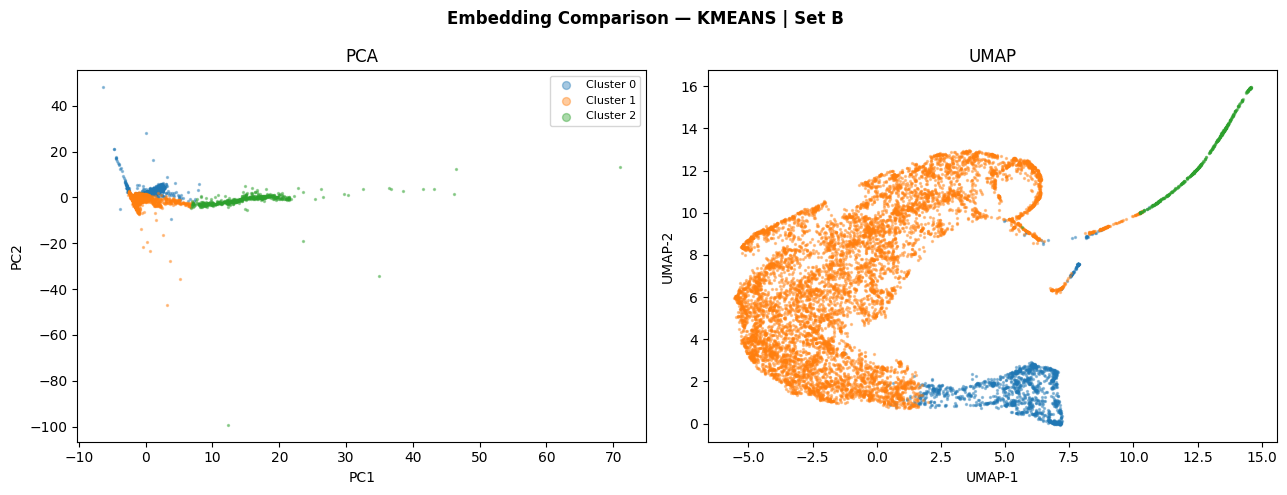

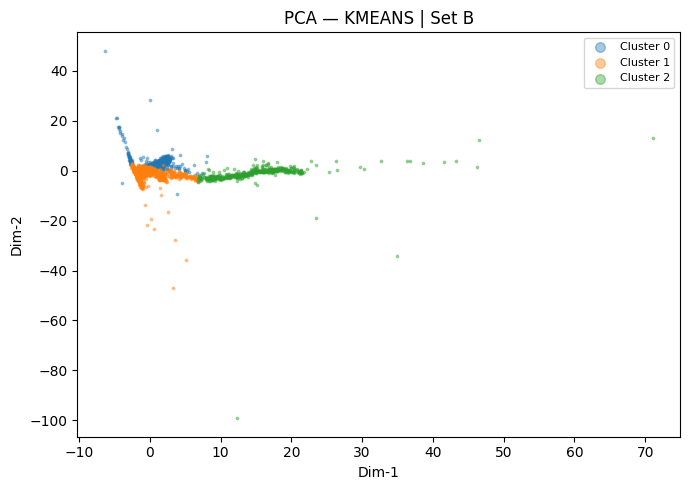

[Part 7] Cluster-to-class mapping:
true_class  GALAXY  QSO  STAR dominant_class  purity
cluster                                             
0             1124   21    59         GALAXY  0.9336
1             7306  233   566         GALAXY  0.9014
2                4  431     0            QSO  0.9908


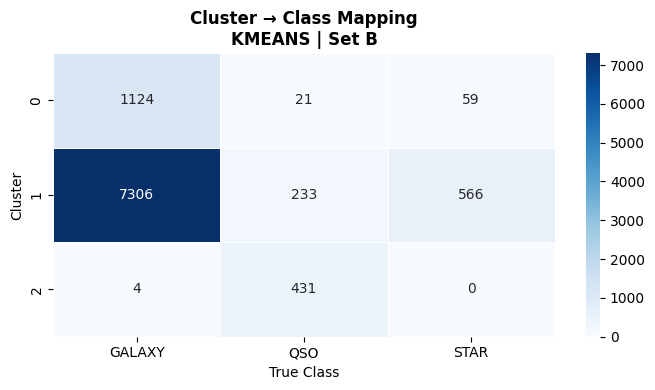


[Part 7] Plotting: GMM | Set B


/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Clustering/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


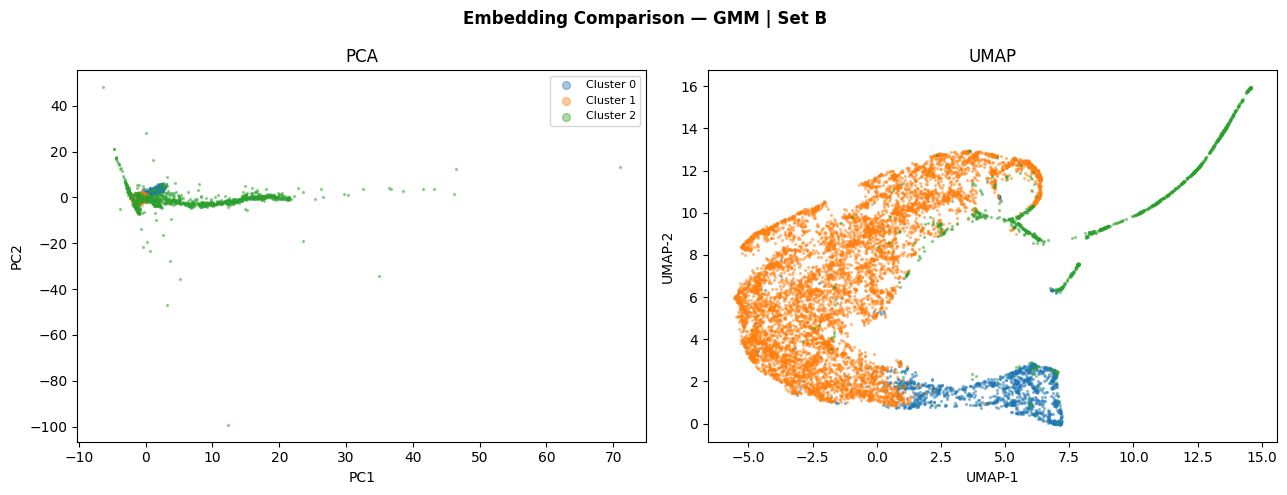

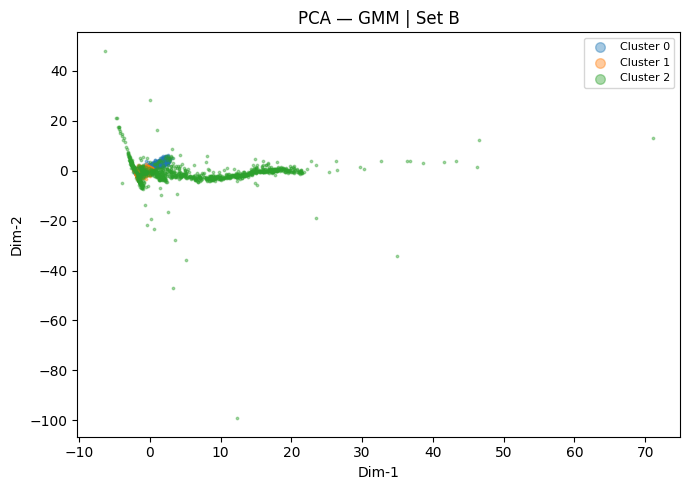

[Part 7] Cluster-to-class mapping:
true_class  GALAXY  QSO  STAR dominant_class  purity
cluster                                             
0             1303    4    33         GALAXY  0.9724
1             6924   45   407         GALAXY  0.9387
2              207  636   185            QSO  0.6187


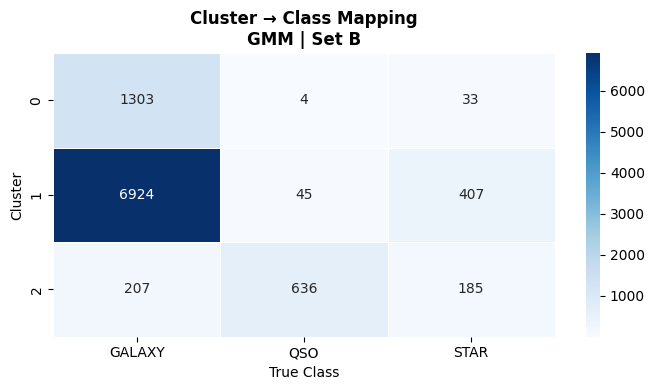


[Part 7] Plotting: AGGLOMERATIVE | Set B


/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Clustering/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


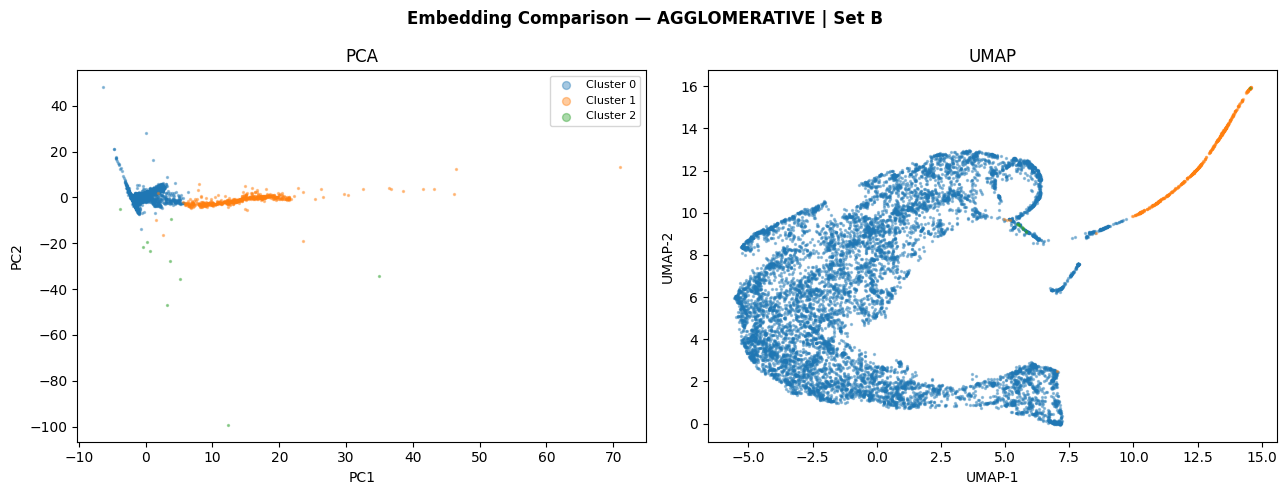

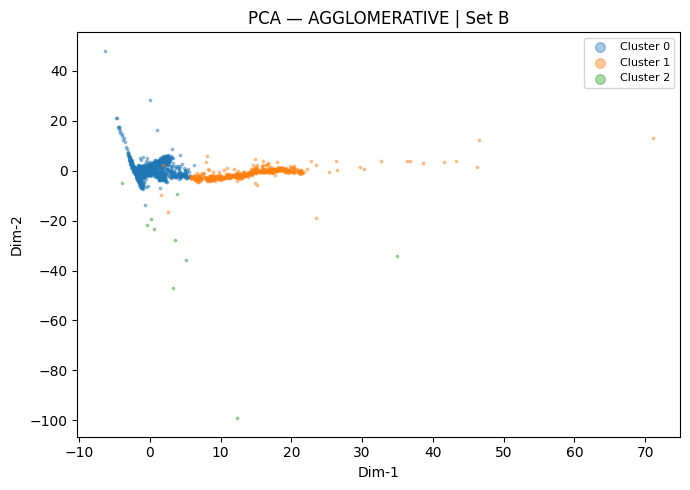

[Part 7] Cluster-to-class mapping:
true_class  GALAXY  QSO  STAR dominant_class  purity
cluster                                             
0             8419  224   625         GALAXY  0.9084
1                8  458     0            QSO  0.9828
2                7    3     0         GALAXY  0.7000


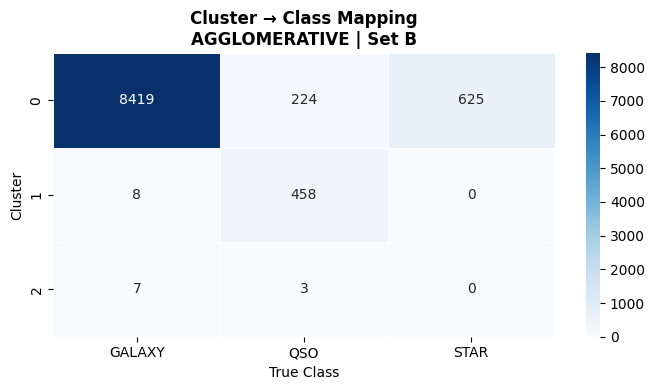


[Part 7] Plotting: SPECTRAL | Set B


/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Clustering/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


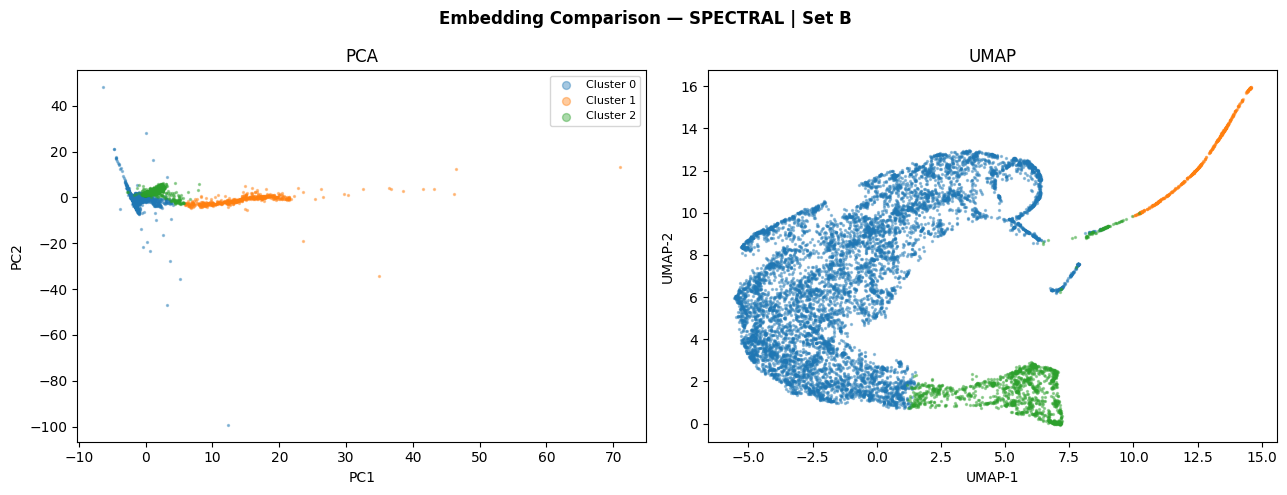

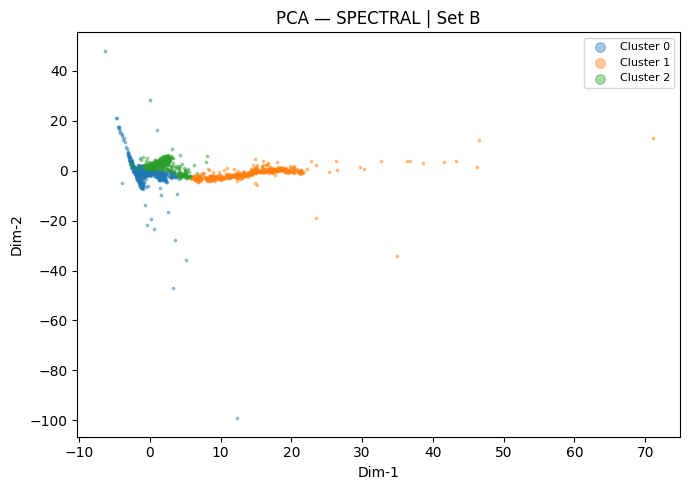

[Part 7] Cluster-to-class mapping:
true_class  GALAXY  QSO  STAR dominant_class  purity
cluster                                             
0             7277  167   623         GALAXY  0.9021
1                4  456     0            QSO  0.9913
2             1153   62     2         GALAXY  0.9474


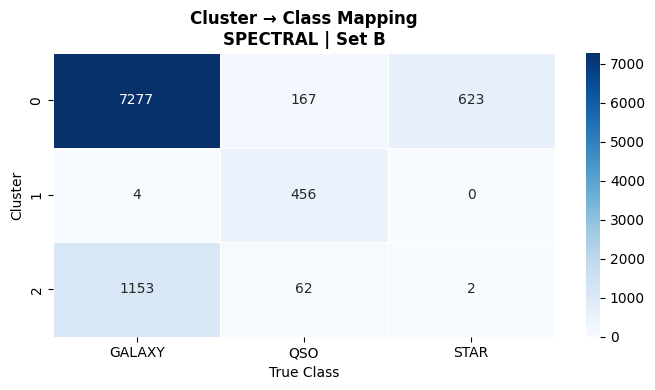


[Part 7] Plotting: DBSCAN | Set B


/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Clustering/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


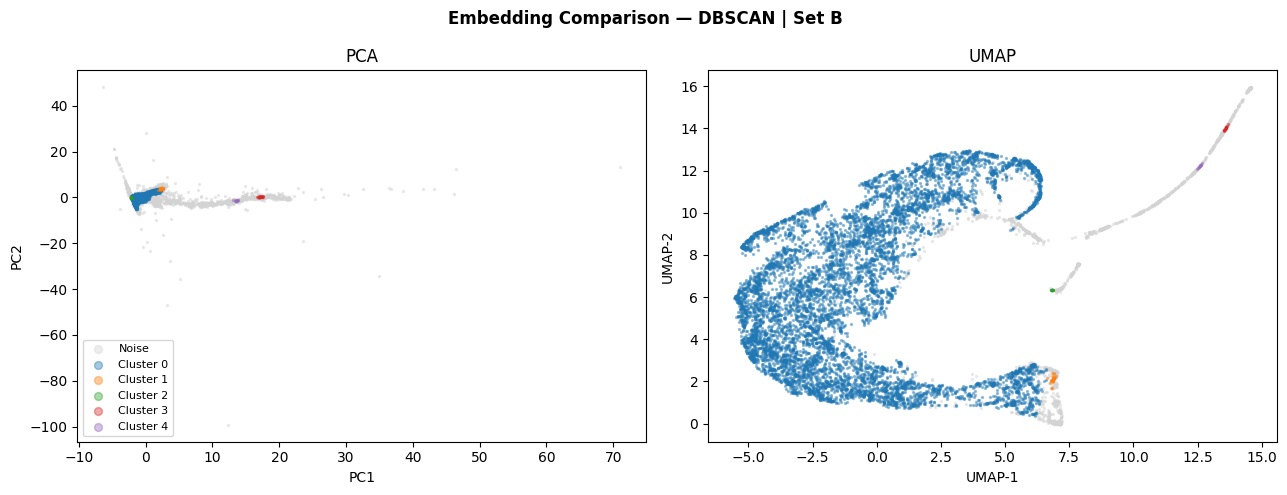

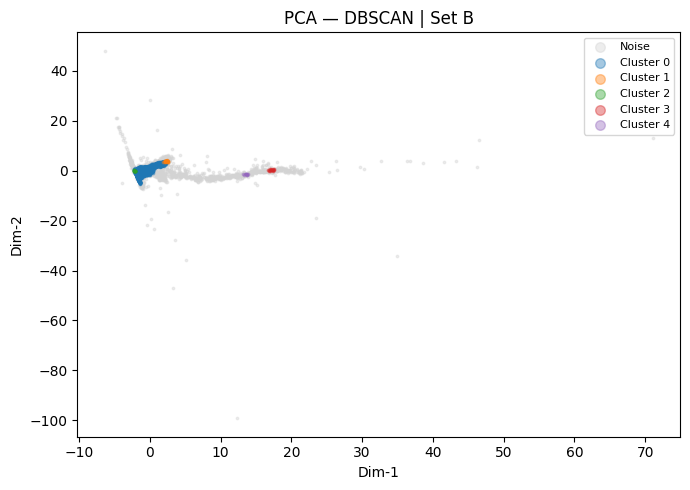

[Part 7] Cluster-to-class mapping:
true_class  GALAXY  QSO  STAR dominant_class  purity
cluster                                             
0             7817   35   447         GALAXY  0.9419
1               28    0     0         GALAXY  1.0000
2                0    0    16           STAR  1.0000
3                0   16     0            QSO  1.0000
4                0   10     0            QSO  1.0000


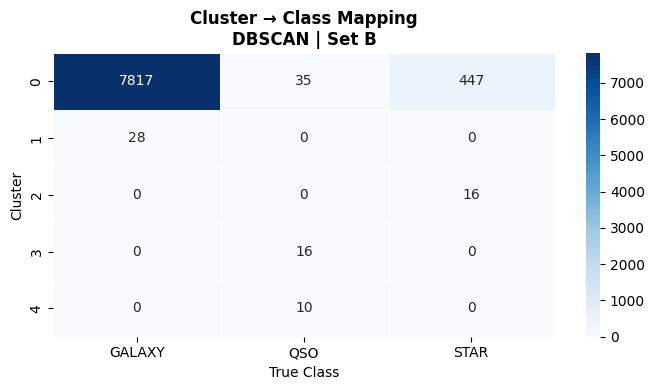


[Part 7] Plotting: HDBSCAN | Set B


/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Clustering/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


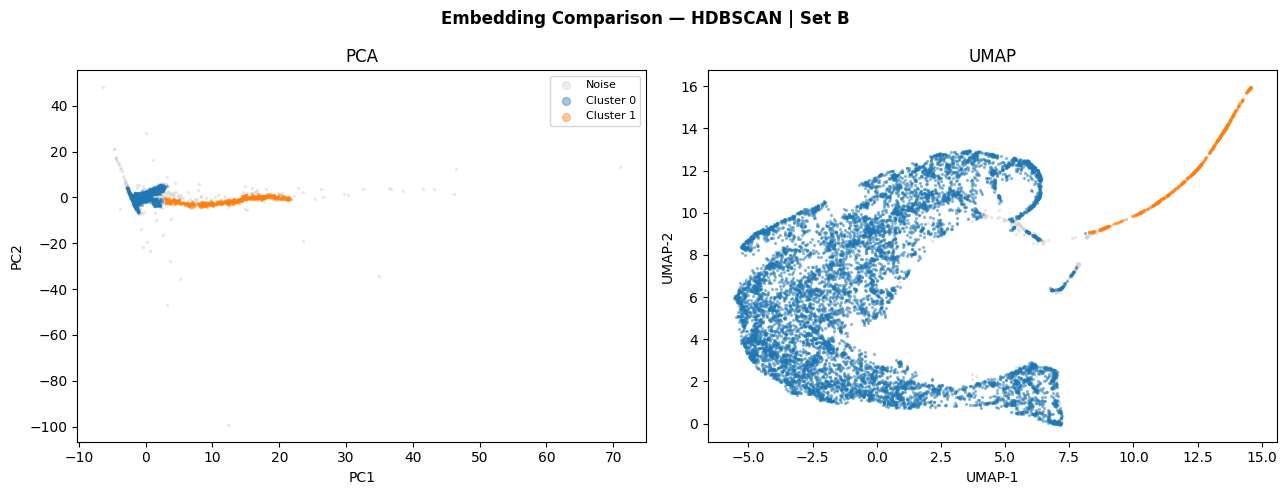

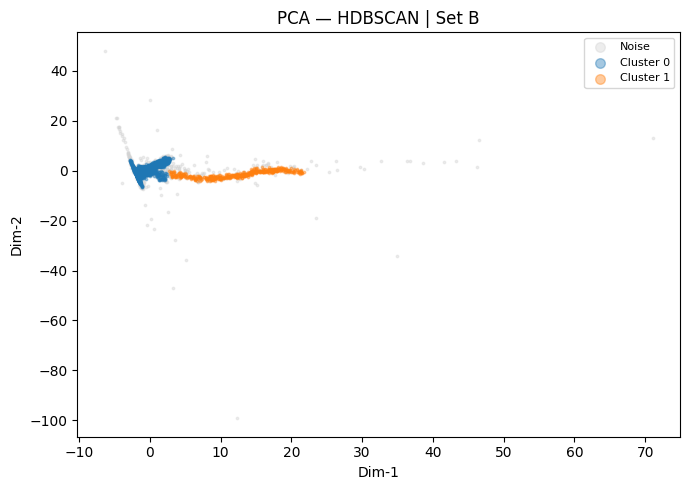

[Part 7] Cluster-to-class mapping:
true_class  GALAXY  QSO  STAR dominant_class  purity
cluster                                             
0             8276  122   553         GALAXY  0.9246
1                2  445     0            QSO  0.9955


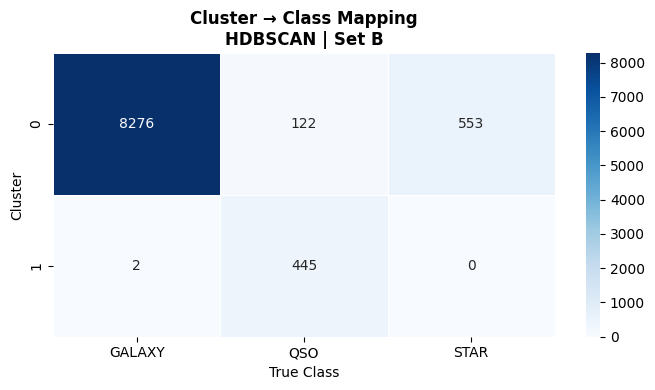

In [24]:
runs_to_plot = [
    ("kmeans", "B"),
    ("gmm", "B"),
    ("agglomerative", "B"),
    ("spectral", "B"),
    ("dbscan", "B"),
]

if ("hdbscan", "B") in all_labels:
    runs_to_plot.append(("hdbscan", "B"))

for algo, set_name in runs_to_plot:
    key = (algo, set_name)
    if key not in all_labels:
        print(f"[Part 7] Skipping missing run: {key}")
        continue

    X = prepared[set_name]["X_scaled"]
    labels = all_labels[key]
    title = f"{algo.upper()} | Set {set_name}"

    print(f"\n[Part 7] Plotting: {title}")

    # 2) Side-by-side embedding comparison (PCA + UMAP if available)
    fig = visualise.plot_embedding_comparison(X, labels, y, title=title)
    plt.show()

    # 3) Optional single embedding (cleaner per-view)
    fig = visualise.plot_embedding(X, labels, method="pca", title=title)
    plt.show()

    # 4) Cluster -> class mapping table + heatmap
    mapping = evaluate.cluster_class_mapping(labels, y)
    print("[Part 7] Cluster-to-class mapping:")
    print(mapping.to_string())

    fig = visualise.plot_confusion_heatmap(mapping, title=title)
    plt.show()


## Part 8: Evaluation

[Part 8] Canonical summary (top 10 by silhouette):
    algorithm feature_set  k  silhouette  davies_bouldin  calinski_harabasz    ari    nmi  purity
agglomerative           B  3      0.8172          0.8464            5922.71 0.4532 0.4113  0.9117
      hdbscan           B  2      0.8089          0.4713           14093.94 0.5168 0.4940  0.9280
      hdbscan      CUSTOM  2      0.7888          0.4812           10641.51 0.5146 0.4945  0.9294
      hdbscan           C  2      0.7537          0.5063            7361.07 0.5165 0.4936  0.9365
       kmeans           A  3      0.5886          0.6608           12047.47 0.3212 0.2751  0.9049
       kmeans           B  3      0.5621          0.7771            5983.17 0.2231 0.2567  0.9094
agglomerative           A  3      0.5485          0.6553           10513.39 0.2840 0.3252  0.9122
       kmeans           C  3      0.5474          0.7888            5343.24 0.2714 0.2674  0.9109
       dbscan           A 12      0.5474          0.6772           

/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Clustering/astral_pipeline/visualise.py:424: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


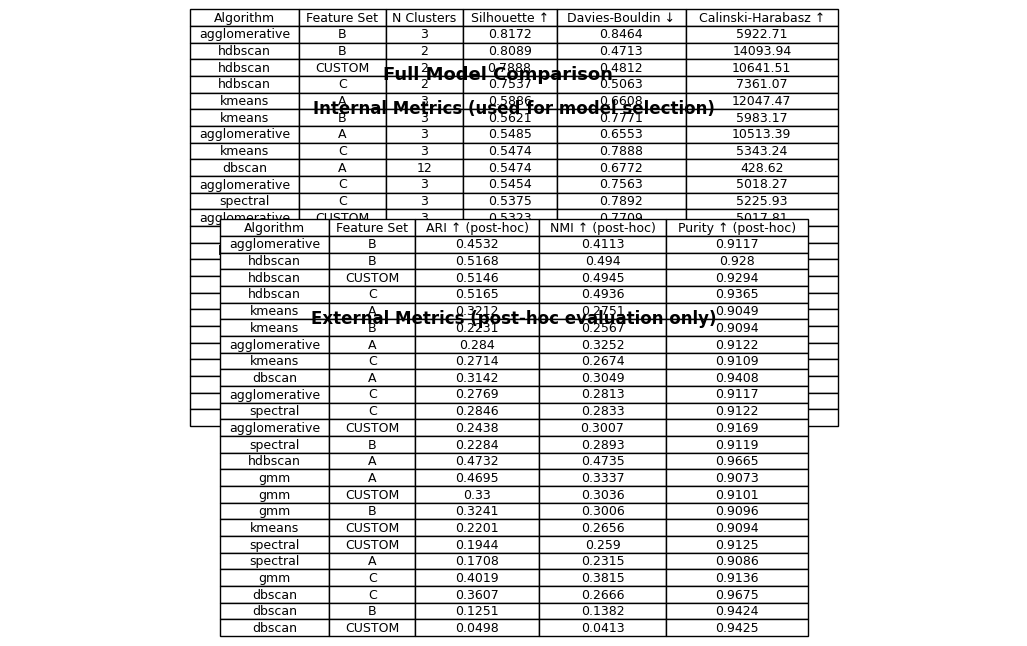


[Part 8] Final selected run:
  Algorithm:        agglomerative
  Feature Set:      B
  N Clusters:       3
  Silhouette:       0.8172
  Davies-Bouldin:   0.8464
  Calinski-Harabasz:5922.71
  ARI (post-hoc):   0.4532
  NMI (post-hoc):   0.4113
  Purity (post-hoc):0.9117

[Part 8] Top 3 runs:
    algorithm feature_set  k  silhouette  davies_bouldin  calinski_harabasz    ari    nmi  purity
agglomerative           B  3      0.8172          0.8464            5922.71 0.4532 0.4113  0.9117
      hdbscan           B  2      0.8089          0.4713           14093.94 0.5168 0.4940  0.9280
      hdbscan      CUSTOM  2      0.7888          0.4812           10641.51 0.5146 0.4945  0.9294


In [25]:
summary = evaluate.build_summary_table(all_results)

print("[Part 8] Canonical summary (top 10 by silhouette):")
print(summary.head(10).to_string(index=False))

# 2) Build display-friendly summary (for report)
summary_display = evaluate.to_display_summary(summary)

print("\n[Part 8] Display summary (top 10):")
print(summary_display.head(10).to_string(index=False))

# 3) Plot tabular comparison figure
fig = visualise.plot_summary_table(summary)  # accepts canonical lowercase now
plt.show()

# 4) Pick final model (example rule: highest silhouette, then lowest DB)
# (already sorted by silhouette descending in build_summary_table)
best = summary.iloc[0]

print("\n[Part 8] Final selected run:")
print(f"  Algorithm:        {best['algorithm']}")
print(f"  Feature Set:      {best['feature_set']}")
print(f"  N Clusters:       {best['k']}")
print(f"  Silhouette:       {best['silhouette']}")
print(f"  Davies-Bouldin:   {best['davies_bouldin']}")
print(f"  Calinski-Harabasz:{best['calinski_harabasz']}")
print(f"  ARI (post-hoc):   {best['ari']}")
print(f"  NMI (post-hoc):   {best['nmi']}")
print(f"  Purity (post-hoc):{best['purity']}")

# 5) Optional: show top-3 alternatives for discussion
print("\n[Part 8] Top 3 runs:")
print(summary.head(3).to_string(index=False))


---
## Part 9 — Discussion & Conclusions

### Did k=3 emerge naturally?

*(Discuss based on Phase 3 results.)*

If yes → the classes occupy distinct photometric regions that automated methods correctly identify.  
If no → photometric degeneracy exists; some object types cannot be reliably separated by magnitude and color alone.

---

### Which feature set performed best?

*(Discuss based on Phase 6 summary table.)*

Expected: Set B (color indices + redshift) > Set A (raw bands + redshift), because color indices directly encode spectral type without brightness confounding. Set C may not improve on B significantly due to redundancy.

---

### Hardest classes to separate?

Stars and low-redshift QSOs (z < 0.5) have overlapping colors in photometric space — a well-known challenge requiring spectroscopy to resolve definitively. Galaxies are generally easiest to isolate.

---

### Effect of class imbalance

85% galaxy dominance biases K-Means toward large galaxy clusters. GMM with full covariance handles this better, allowing clusters of different shapes and sizes.

---

### Metric separation — the critical methodological point

All algorithm/hyperparameter choices used **internal metrics only**. The agreement between our clusters and the true labels (ARI/NMI/Purity) is a **result**, not a design choice. This distinction is essential for honest unsupervised evaluation.

---

### Limitations & future directions

- **UMAP**: non-linear reduction would improve cluster visualisation (`pip install umap-learn`)
- **Semi-supervised**: constrained clustering if partial labels are available
- **Feature importance**: SHAP-based tools to explain which features drive each cluster
- **Probabilistic outputs**: GMM posteriors to flag photometrically ambiguous objects for follow-up
